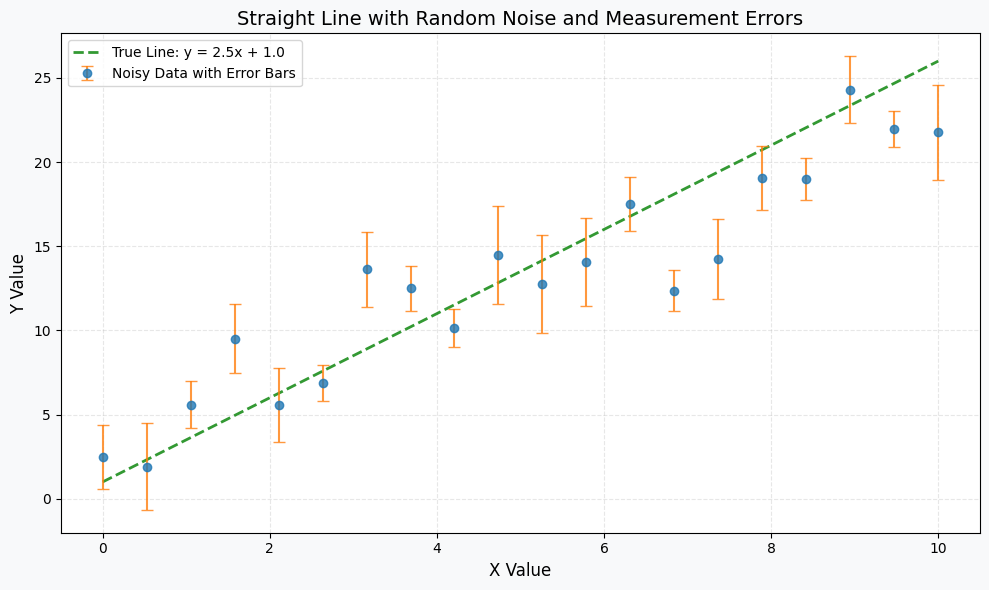

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(42)

# Create figure with light background
plt.figure(figsize=(10, 6), facecolor='#f8f9fa')

# Generate clean line data
x = np.linspace(0, 10, 20)
y_true = 2.5 * x + 1.0  # True linear relationship

# Generate random noise
noise_magnitude = 3.0
noise = np.random.normal(0, noise_magnitude, len(x))

# Generate random error bars (different for each point)
errors = np.random.uniform(1.0, 3.0, len(x))

# Create noisy data with error bars
y_noisy = y_true + noise

# Plot true line
plt.plot(x, y_true, 'g--', linewidth=2, alpha=0.8, 
         label='True Line: y = 2.5x + 1.0')

# Plot noisy data with error bars
plt.errorbar(x, y_noisy, yerr=errors, fmt='o', color='#1f77b4', 
             ecolor='#ff7f0e', elinewidth=1.5, capsize=4, alpha=0.8,
             label='Noisy Data with Error Bars')

# Add labels and title
plt.title('Straight Line with Random Noise and Measurement Errors', fontsize=14)
plt.xlabel('X Value', fontsize=12)
plt.ylabel('Y Value', fontsize=12)
plt.grid(alpha=0.3, linestyle='--')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

In [7]:
import pypolychord
from pypolychord.settings import PolyChordSettings
from pypolychord.priors import UniformPrior

# Define number of dimensions: [m, c]
nDims = 2
nDerived = 0 # derived parameters

# Likelihood for line fitting with measurement errors
def likelihood(theta):
    m, c = theta
    model = m * x + c
    residuals = (y_noisy - model) / errors
    logL = -0.5 * np.sum(residuals**2 + np.log(2 * np.pi * errors**2))
    return logL, []

# Uniform prior: m in [0, 5], c in [-10, 10]
def prior(hypercube):
    prior = []
    prior.append(UniformPrior(0.,5.)(hypercube[0]))
    prior.append(UniformPrior(-10,10)(hypercube[1]))
    return prior

# Optional dumper
def dumper(live, dead, logweights, logZ, logZerr):
    print("Last dead point:", dead[-1])

# PolyChord settings
settings = PolyChordSettings(nDims, nDerived)
settings.file_root = 'linefit_poly'
settings.nlive = 30
settings.do_clustering = True
settings.read_resume = False

In [8]:
output = pypolychord.run_polychord(likelihood, nDims, nDerived, settings, prior, dumper)

Last dead point: [ 2.99080980e-01  8.12359439e+00 -1.36154481e+03 -1.81522406e+02]
PolyChord: MPI is already initilised, not initialising, and will not finalize

PolyChord: Next Generation Nested Sampling
copyright: Will Handley, Mike Hobson & Anthony Lasenby
  version: 1.20.2
  release: 1st June 2021
    email: wh260@mrao.cam.ac.uk

Run Settings
nlive    :      30
nDims    :       2
nDerived :       0
Doing Clustering
Synchronous parallelisation
Generating equally weighted posteriors
Generating weighted posteriors
Clustering on posteriors
Writing a resume file to chains/linefit_poly.resume

generating live points


all live points generated

Speed  1 =  0.113E-04 seconds
number of repeats:           10
started sampling

________________
lives      | 30 |
phantoms   |173 |
posteriors | 31 |
equals     |  1 |
‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾
ncluster   =       1 /       1
ndead      =                  31
nposterior =                  31
nequals    =                   1
nlike      =                 562


In [12]:
paramnames = [('m','M (km/sec/Mpc)'),('c', 'C')]
output.make_paramnames_files(paramnames)
posterior = output.posterior


chains/linefit_poly.txt
Removed no burn in


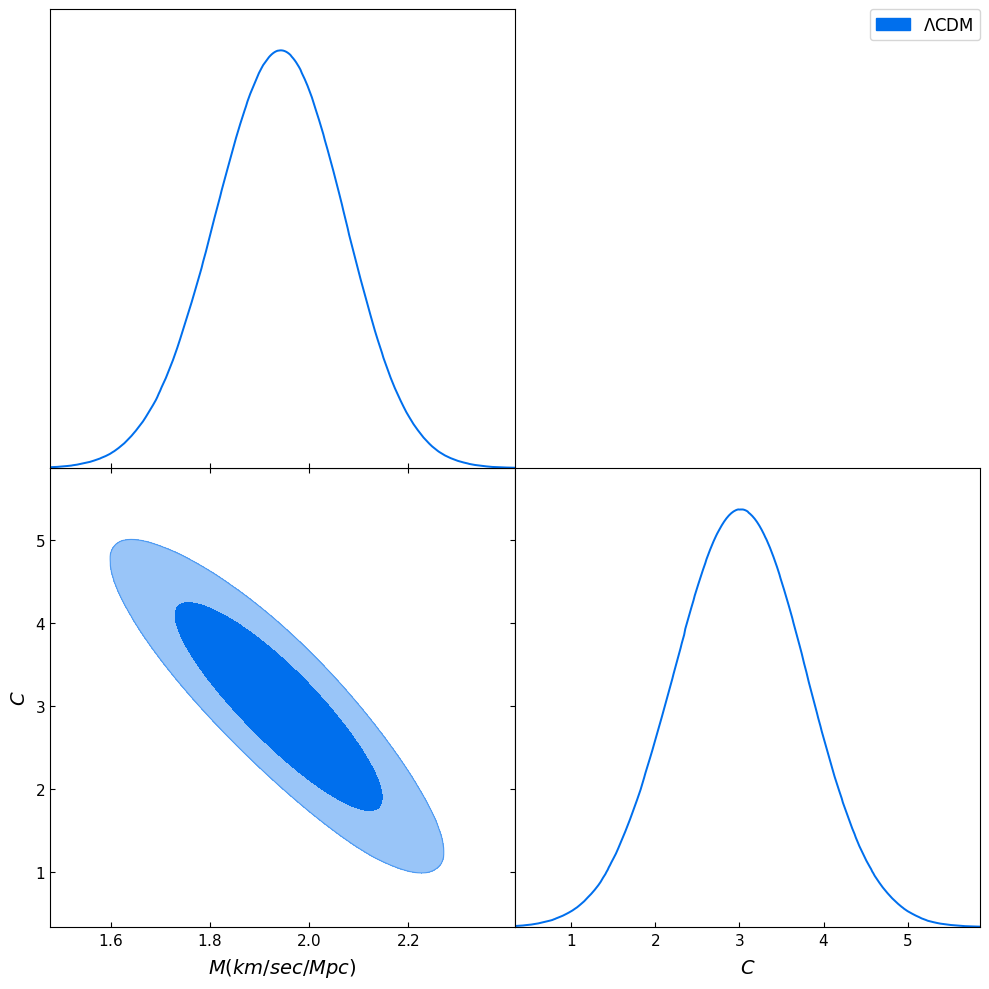

In [13]:
import getdist

from getdist import plots, MCSamples

g = getdist.plots.getSubplotPlotter(width_inch=10)
g.triangle_plot([posterior], ('m','c') ,filled=True, legend_labels=[r'$\Lambda$CDM'])
#g.export('corFull.pdf')